In [44]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
%matplotlib inline

# Вариант 6

### Задание

1. Ознакомиться с теоретической частью.

2. Для заданных дискретных сигналов ( ) и y( ) (либо специально подобранных музыкальных файлов) выполнить следующие задания (в соответствии с заданным вариантом, выданным преподавателем):

    - реализовать операцию свертки двух сигналов;
    
    - реализовать операцию корреляции двух сигналов;
    
    - для сигналов x( ) и y( ), а также результата выполнения операции свертки выполнить прямое и обратное преобразование Фурье;
    
    - построить графики амплитудного и фазового спектра сигналов;
    
    - построить графики сигналов во временной области;
    
    - экспериментально проверить корректность схем вычисления свертки и корреляции (в соответствии с рисунками 15 и 16).

3. Сравнить полученные результаты при разных значениях, оценить эффективность алгоритмов в зависимости от .

> Примечание. Прямое и обратное преобразования Фурье, вычисление операций свертки и корреляции должны быть представлены в двух вариантах – реализованные студентом самостоятельно и с использованием Open Source библиотек.

4. Оформить итоговый отчет с указанием исходных данных, результатов работы, построенных графиков, выводами о результатах работы.

#### Графики
<!-- 1.	x(t)	x(t) -->
<!-- 2.	y(t)	y(t) -->
3.	x(t)	ДПФ: амплитудный спектр
4.	x(t)	ДПФ: фазовый спектр
5.	x(t)	ОДПФ
6.	x(t)	БПФ: амплитудный спектр
7.	x(t)	БПФ: фазовый спектр
8.	x(t)	ОБПФ
9.	y(t)	ДПФ: амплитудный спектр
10.	y(t)	ДПФ: фазовый спектр
11.	y(t)	ОДПФ
12.	y(t)	БПФ: амплитудный спектр
13.	y(t)	БПФ: фазовый спектр
14.	y(t)	ОБПФ
15.	x(t) y(t)	Свертка
16.	x(t) y(t)	Свертка через БПФ
17.	x(t) y(t)	Корреляция
18.	x(t) y(t)	Корреляция через БПФ
##### С использованием Open Source библиотек.	
19.	x(t)	БПФ: амплитудный спектр
20.	x(t)	БПФ: фазовый спектр
21.	y(t)	БПФ: амплитудный спектр
22.	y(t)	БПФ: фазовый спектр
<!-- 23.	x(t) y(t)	Свертка -->
<!-- 25.	x(t) y(t)	Корреляция -->

- x(t) = Орган С4

In [67]:
A_x = [1, 0.5, 0.3, 0.1]
f0_x = 262 #Hz
h_x = [1, 2, 4, 8]
phi_x = 0

- y(t) = Орган E4

In [68]:
A_y = [1, 0.4, 0.2, 0.1]
f0_y = 330 #Hz
h_y = [1, 2, 4, 8]
phi_y = 0

### Графики

In [177]:
def plot(y, x, title: str|None = None):
    plt.plot(x, y)
    plt.title(title)
    plt.grid(True)
    plt.show() 

In [178]:
def s(t, A, h, f0, phi):
    assert(len(A) == len(h))
    return sum(
        A[i] * np.sin(2*pi * h[i] * f0 * t + phi)
        for i in range(0, len(A))
    )

GRAPH_FREQ = 3/min(f0_x, f0_y)
t = np.linspace(0, GRAPH_FREQ, 1024)

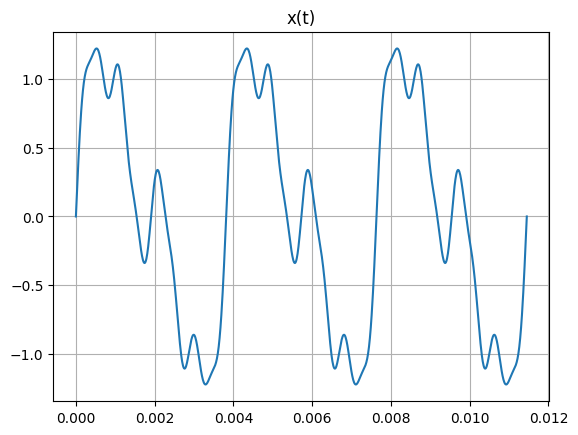

In [179]:
x = s(t, A_x, h_x, f0_x, phi_x)
plot(x, t, "x(t)")

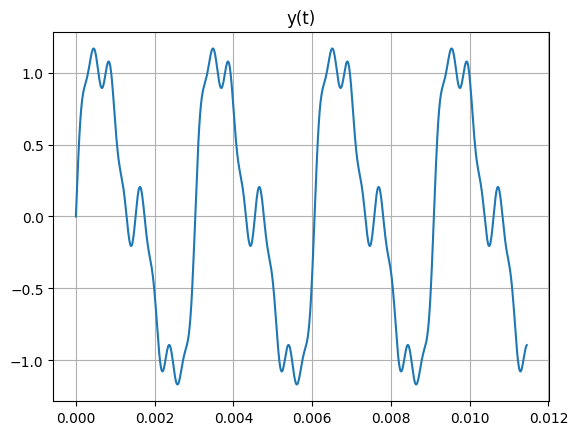

In [180]:
y = s(t, A_y, h_y, f0_y, phi_y)
plot(y, t, "y(t)")

### С использованием библиотек

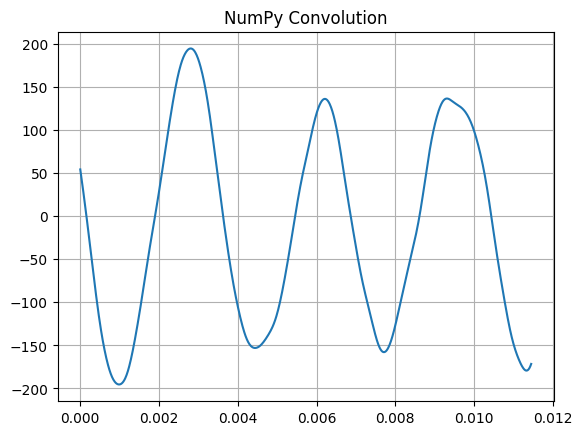

In [183]:
np_conv = np.convolve(x, y, mode="same")
plot(np_conv, t, "NumPy Convolution")

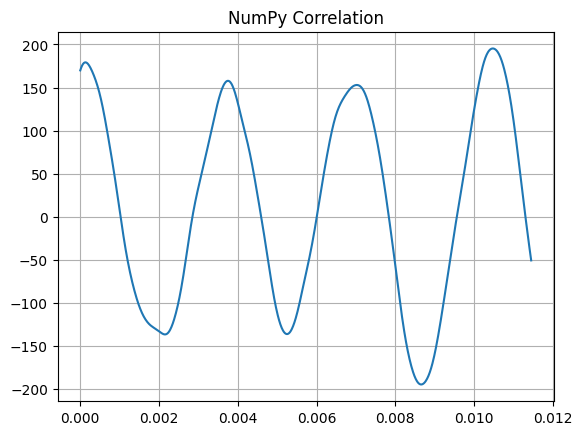

In [184]:
np_corr = np.correlate(x, y, mode="same")
plot(np_corr, t, "NumPy Correlation")

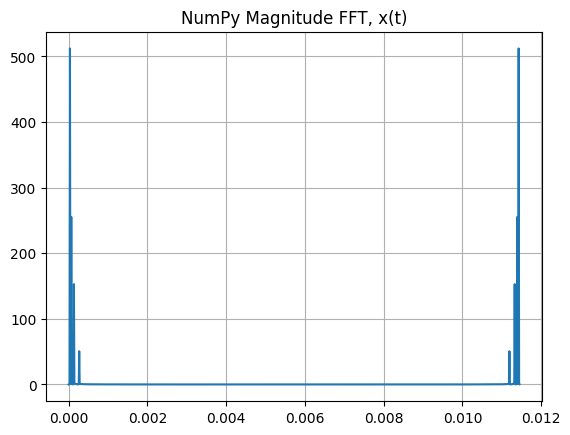

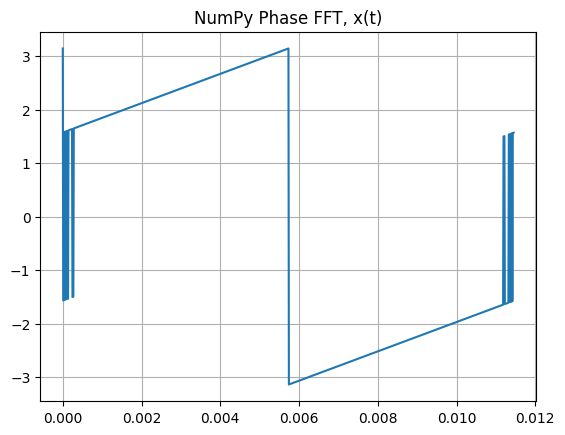

In [196]:
np_fft = np.fft.fft(x)
plot(np.abs(np_fft), t, "NumPy Magnitude FFT, x(t)")
plot(np.angle(np_fft), t, "NumPy Phase FFT, x(t)")

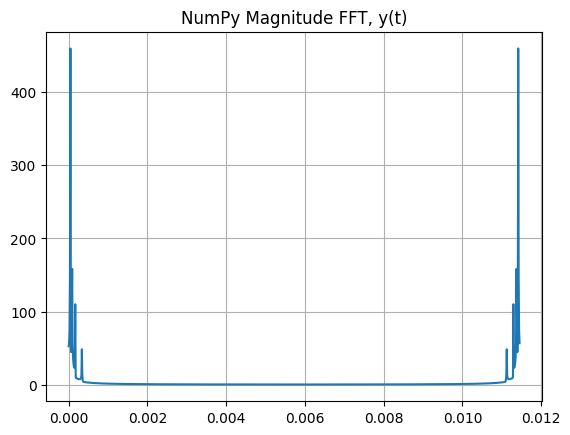

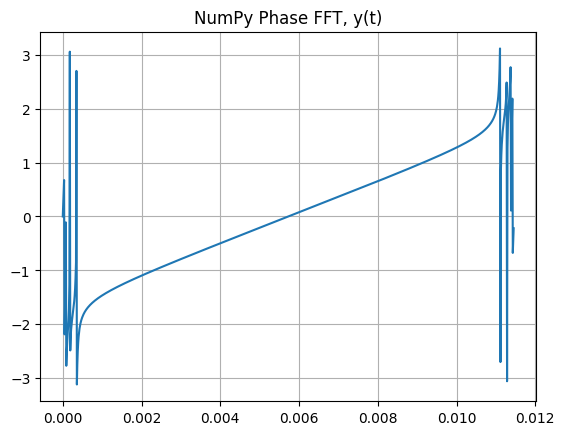

In [197]:
np_fft = np.fft.fft(y)
plot(np.abs(np_fft), t, "NumPy Magnitude FFT, y(t)")
plot(np.angle(np_fft), t, "NumPy Phase FFT, y(t)")